In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
jawadali1045_20k_multi_class_crop_disease_images_path = kagglehub.dataset_download('jawadali1045/20k-multi-class-crop-disease-images')

print('Data source import complete.')


C:\Users\Betina Kuriakose\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data source import complete.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import ResNet50V2, VGG16, VGG19, MobileNetV2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as preprocess_resnet50v2
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.vgg19 import preprocess_input as preprocess_vgg19
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2
from tensorflow.keras.utils import to_categorical

In [3]:
tf.__version__,cv2.__version__

('2.15.0', '4.12.0')

In [4]:
!python --version

Python 3.11.9


In [5]:
print("Available devices:")
for device in tf.config.list_physical_devices():
    print(device)

Available devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')


# Data spliting into two folders

In [6]:
import os

train_folder = 'datasets/jawadali1045/20k-multi-class-crop-disease-images/versions/1/Train'
val_folder = 'datasets/jawadali1045/20k-multi-class-crop-disease-images/versions/1/Validation'

# Get class names (same in Train and Validation)
class_names = sorted(os.listdir(train_folder))
print(f"Classes: {class_names}, Total: {len(class_names)}")

# Count images in Train and Validation
total_train_images = sum(len(os.listdir(os.path.join(train_folder, cls))) for cls in class_names if os.path.isdir(os.path.join(train_folder, cls)))
total_val_images = sum(len(os.listdir(os.path.join(val_folder, cls))) for cls in class_names if os.path.isdir(os.path.join(val_folder, cls)))

print(f"Total images in Train: {total_train_images}")
print(f"Total images in Validation: {total_val_images}")
print(f"Total images in dataset: {total_train_images + total_val_images}")

Classes: ['American Bollworm on Cotton', 'Anthracnose on Cotton', 'Army worm', 'Becterial Blight in Rice', 'Brownspot', 'Common_Rust', 'Cotton Aphid', 'Flag Smut', 'Gray_Leaf_Spot', 'Healthy Maize', 'Healthy Wheat', 'Healthy cotton', 'Leaf Curl', 'Leaf smut', 'Mosaic sugarcane', 'RedRot sugarcane', 'RedRust sugarcane', 'Rice Blast', 'Sugarcane Healthy', 'Tungro', 'Wheat Brown leaf Rust', 'Wheat Stem fly', 'Wheat aphid', 'Wheat black rust', 'Wheat leaf blight', 'Wheat mite', 'Wheat powdery mildew', 'Wheat scab', 'Wheat___Yellow_Rust', 'Wilt', 'Yellow Rust Sugarcane', 'bacterial_blight in Cotton', 'bollrot on Cotton', 'bollworm on Cotton', 'cotton mealy bug', 'cotton whitefly', 'maize ear rot', 'maize fall armyworm', 'maize stem borer', 'pink bollworm in cotton', 'red cotton bug', 'thirps on  cotton'], Total: 42
Total images in Train: 15342
Total images in Validation: 2889
Total images in dataset: 18231


In [7]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Paths
train_folder = 'datasets/jawadali1045/20k-multi-class-crop-disease-images/versions/1/Train'
val_folder = 'datasets/jawadali1045/20k-multi-class-crop-disease-images/versions/1/Validation'
new_train_folder = '/kaggle/working/NewTrain'
test_folder = '/kaggle/working/Test'

# Create NewTrain and Test folders
os.makedirs(new_train_folder, exist_ok=True)
os.makedirs(test_folder, exist_ok=True)

# Set the test split ratio (20% for Test)
test_ratio = 0.20

# Iterate over each class in the Train folder
for class_name in os.listdir(train_folder):
    class_path = os.path.join(train_folder, class_name)

    if not os.path.isdir(class_path):
        continue

    # Get all image file names in the current class folder
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    # Split images into Train and Test
    train_imgs, test_imgs = train_test_split(images, test_size=test_ratio, random_state=42)

    # Create class folders in NewTrain and Test
    new_train_class_folder = os.path.join(new_train_folder, class_name)
    test_class_folder = os.path.join(test_folder, class_name)
    os.makedirs(new_train_class_folder, exist_ok=True)
    os.makedirs(test_class_folder, exist_ok=True)

    # Copy remaining Train images to NewTrain
    for img in train_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(new_train_class_folder, img)
        shutil.copy2(src, dst)

    # Copy Test images to Test
    for img in test_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(test_class_folder, img)
        shutil.copy2(src, dst)

print("NewTrain and Test folders created successfully.")

# Verify the split
total_new_train_images = sum(len(os.listdir(os.path.join(new_train_folder, cls))) for cls in os.listdir(new_train_folder) if os.path.isdir(os.path.join(new_train_folder, cls)))
total_test_images = sum(len(os.listdir(os.path.join(test_folder, cls))) for cls in os.listdir(test_folder) if os.path.isdir(os.path.join(test_folder, cls)))
print(f"Total images in NewTrain: {total_new_train_images}")
print(f"Total images in Test: {total_test_images}")
print(f"Total images in Validation: {total_val_images}")
print(f"Total images across all sets: {total_new_train_images + total_val_images + total_test_images}")

NewTrain and Test folders created successfully.
Total images in NewTrain: 12254
Total images in Test: 3081
Total images in Validation: 2889
Total images across all sets: 18224


# Data Visualization

/kaggle/working/NewTrain\American Bollworm on Cotton
/kaggle/working/NewTrain\Anthracnose on Cotton
/kaggle/working/NewTrain\Army worm
/kaggle/working/NewTrain\bacterial_blight in Cotton
/kaggle/working/NewTrain\Becterial Blight in Rice
/kaggle/working/NewTrain\bollrot on Cotton
/kaggle/working/NewTrain\bollworm on Cotton
/kaggle/working/NewTrain\Brownspot
/kaggle/working/NewTrain\Common_Rust
/kaggle/working/NewTrain\Cotton Aphid
/kaggle/working/NewTrain\cotton mealy bug
/kaggle/working/NewTrain\cotton whitefly
/kaggle/working/NewTrain\Flag Smut
/kaggle/working/NewTrain\Gray_Leaf_Spot
/kaggle/working/NewTrain\Healthy cotton
/kaggle/working/NewTrain\Healthy Maize
/kaggle/working/NewTrain\Healthy Wheat
/kaggle/working/NewTrain\Leaf Curl
/kaggle/working/NewTrain\Leaf smut
/kaggle/working/NewTrain\maize ear rot
/kaggle/working/NewTrain\maize fall armyworm
/kaggle/working/NewTrain\maize stem borer
/kaggle/working/NewTrain\Mosaic sugarcane
/kaggle/working/NewTrain\pink bollworm in cotton
/ka

100%|██████████████████████████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 36.31it/s]


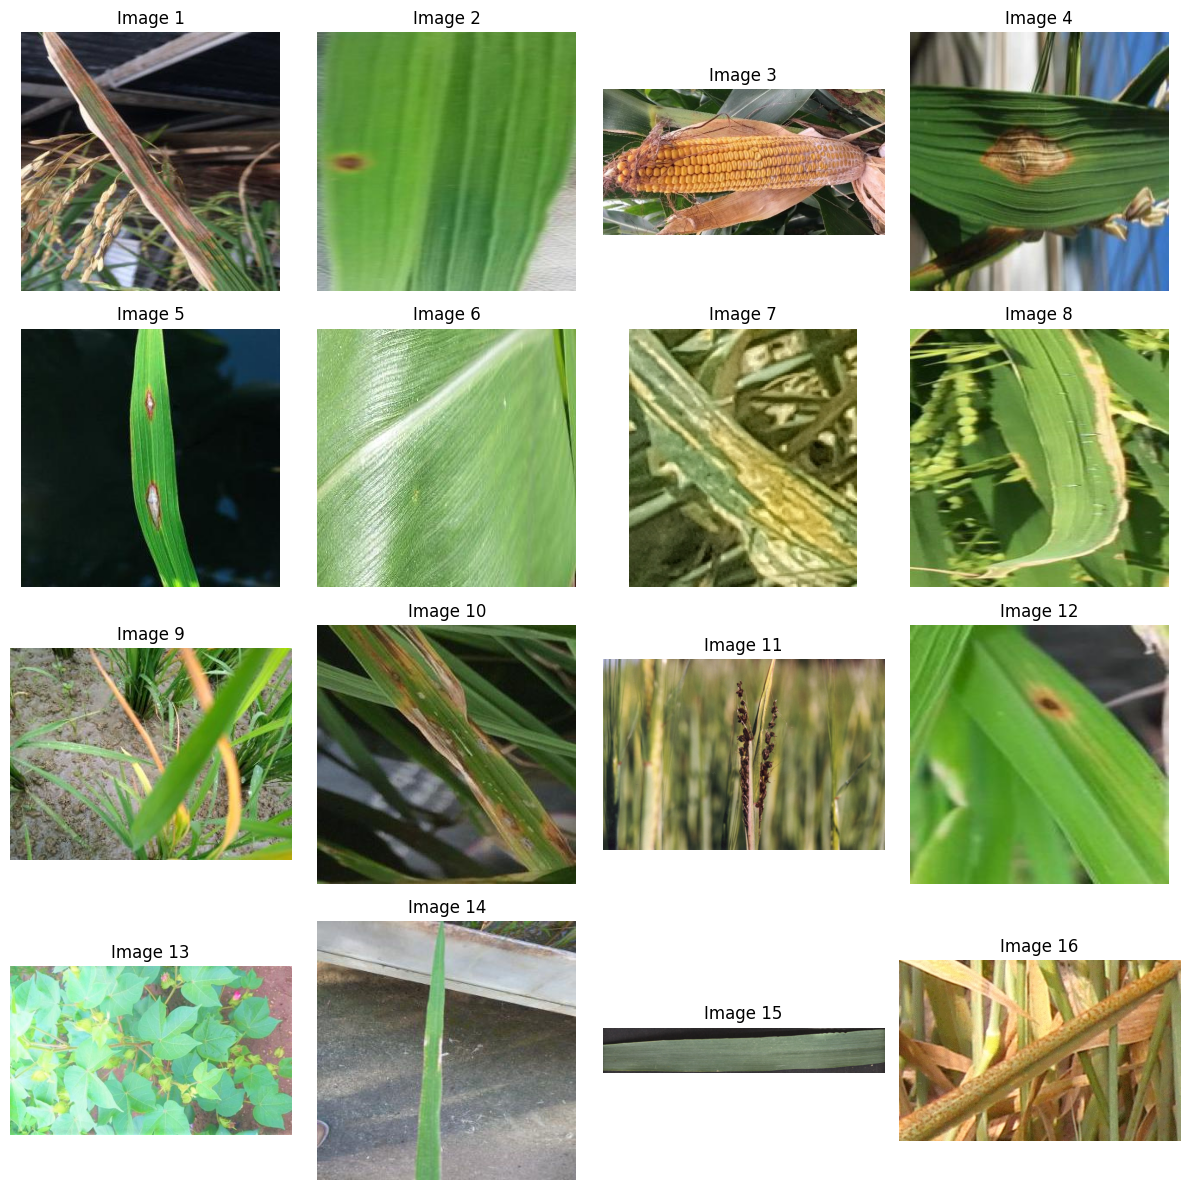

In [8]:
# Get all image paths
images = []
for folder in os.listdir(new_train_folder):
    path = os.path.join(new_train_folder,folder)
    print(path)
    for img in os.listdir(path):
        if img.endswith(('.jpg', '.png', '.webp')):
            images.append(os.path.join(path, img))

# Pick 16 random images
random_images = random.sample(images, 16)

# Plot them
plt.figure(figsize=(12, 12))
for i, img_path in enumerate(tqdm(random_images)):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img,cmap='gray')
    plt.axis('off')
    plt.title(f'Image {i+1}')

plt.tight_layout()
plt.show()

# CNN Model

# CNN Data Generators

In [9]:
val_path = 'datasets/jawadali1045/20k-multi-class-crop-disease-images/versions/1/Validation'
train_path = '/kaggle/working/NewTrain'
test_path = '/kaggle/working/Test'

In [10]:
IMG_SIZE = 224
batch_size = 32

In [11]:
def cnn_preprocess(x):
    return x/255.0

In [12]:
cnn_train_datagen = ImageDataGenerator(preprocessing_function=cnn_preprocess)
cnn_train_generator = cnn_train_datagen.flow_from_directory(
        train_path,
        target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=batch_size,
        class_mode='categorical')

Found 12254 images belonging to 42 classes.


In [13]:
cnn_train_generator.class_indices

{'American Bollworm on Cotton': 0,
 'Anthracnose on Cotton': 1,
 'Army worm': 2,
 'Becterial Blight in Rice': 3,
 'Brownspot': 4,
 'Common_Rust': 5,
 'Cotton Aphid': 6,
 'Flag Smut': 7,
 'Gray_Leaf_Spot': 8,
 'Healthy Maize': 9,
 'Healthy Wheat': 10,
 'Healthy cotton': 11,
 'Leaf Curl': 12,
 'Leaf smut': 13,
 'Mosaic sugarcane': 14,
 'RedRot sugarcane': 15,
 'RedRust sugarcane': 16,
 'Rice Blast': 17,
 'Sugarcane Healthy': 18,
 'Tungro': 19,
 'Wheat Brown leaf Rust': 20,
 'Wheat Stem fly': 21,
 'Wheat aphid': 22,
 'Wheat black rust': 23,
 'Wheat leaf blight': 24,
 'Wheat mite': 25,
 'Wheat powdery mildew': 26,
 'Wheat scab': 27,
 'Wheat___Yellow_Rust': 28,
 'Wilt': 29,
 'Yellow Rust Sugarcane': 30,
 'bacterial_blight in Cotton': 31,
 'bollrot on Cotton': 32,
 'bollworm on Cotton': 33,
 'cotton mealy bug': 34,
 'cotton whitefly': 35,
 'maize ear rot': 36,
 'maize fall armyworm': 37,
 'maize stem borer': 38,
 'pink bollworm in cotton': 39,
 'red cotton bug': 40,
 'thirps on  cotton': 41}

## CNN Modeling

In [14]:
cnn_model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),
    keras.layers.Dropout(0.4),

    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dense(units=64, activation='relu'),
    keras.layers.Dense(units=64, activation='relu'),

    keras.layers.Dense(units=len(cnn_train_generator.class_indices), activation='softmax', dtype='float32')
])

In [15]:
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 64)      1792      
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 64)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

In [16]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='CNN_best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
]

In [17]:
cnn_model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy(),
               metrics=['accuracy',keras.metrics.Precision(name='precision'),keras.metrics.Recall(name='recall')
])

In [18]:
cnn_history = cnn_model.fit(
        cnn_train_generator,
        epochs = 20,
        validation_data = cnn_train_generator,
        callbacks = callbacks
        )

Epoch 1/20


129/383 [=========>....................] - ETA: 18:57 - loss: 2.7647 - accuracy: 0.2587 - precision: 0.8222 - recall: 0.0862

KeyboardInterrupt: 

In [ ]:
# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# 📉 Loss
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(cnn_history.history['val_loss'], label='Val Loss', marker='o', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 📈 Accuracy
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy', marker='o', color='red')
plt.plot(cnn_history.history['val_accuracy'], label='Val Accuracy', marker='o', color='green')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:

# Get all image paths
images = []
for folder in os.listdir(new_train_folder):
    path = os.path.join(new_train_folder,folder)
    print(path)
    for img in os.listdir(path):
        if img.endswith(('.jpg', '.png', '.webp')):
            images.append(os.path.join(path, img))

# Pick 16 random images
random_images = random.sample(images, 16)

# Plot them
plt.figure(figsize=(12, 12))
for i, img_path in enumerate(tqdm(random_images)):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.subplot(4, 4, i + 1)
    plt.imshow(img,cmap='gray')
    plt.axis('off')
    plt.title(f'Image {i+1}')

plt.tight_layout()
plt.show()


# VGG16 Model

## VGG16 Data Generators

In [ ]:
val_path = 'datasets/jawadali1045/20k-multi-class-crop-disease-images/versions/1/Validation'
train_path = '/kaggle/working/NewTrain'
test_path = '/kaggle/working/Test'

In [ ]:
IMG_SIZE = 224
batch_size = 32

In [ ]:
VGG16_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_vgg16)
VGG16_train_generator = VGG16_train_datagen.flow_from_directory(
        train_path,
        target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=batch_size,
        class_mode='categorical')

In [ ]:
VGG16_train_generator.class_indices

In [ ]:
VGG16_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_vgg16)
VGG16_val_generator = VGG16_val_datagen.flow_from_directory(
        val_path,
        target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=batch_size,
        class_mode='categorical')

In [ ]:
VGG16_val_generator.class_indices

## VGG16 Modeling## VGG16 Modeling

In [ ]:
trained_VGG16_layers = VGG16(weights='imagenet',include_top=False,input_shape=(IMG_SIZE,IMG_SIZE,3))

In [ ]:
for layer in trained_VGG16_layers.layers:
    layer.trainable = False


In [ ]:
VGG16_model = keras.models.Sequential([
    trained_VGG16_layers,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(len(VGG16_val_generator.class_indices), activation='softmax')  # use softmax beacuse you should out only one calsss out of many
])

In [ ]:
VGG16_model.summary()

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='VGG16_best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
]

In [ ]:
VGG16_model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy(),
               metrics=['accuracy',keras.metrics.Precision(name='precision'),keras.metrics.Recall(name='recall')
])

In [ ]:
VGG16_history = VGG16_model.fit(
        VGG16_train_generator,
        epochs = 20,
        validation_data = VGG16_val_generator,
        callbacks = callbacks
        )

In [ ]:
# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# 📉 Loss
plt.subplot(1, 2, 1)
plt.plot(VGG16_history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(VGG16_history.history['val_loss'], label='Val Loss', marker='o', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 📈 Accuracy
plt.subplot(1, 2, 2)
plt.plot(VGG16_history.history['accuracy'], label='Train Accuracy', marker='o', color='red')
plt.plot(VGG16_history.history['val_accuracy'], label='Val Accuracy', marker='o', color='green')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# VGG19 Model

In [ ]:
## VGG19 Data Generators

In [ ]:
val_path = '/kaggle/input/20k-multi-class-crop-disease-images/Validation'
train_path = '/kaggle/working/NewTrain'
test_path = '/kaggle/working/Test'

In [ ]:
IMG_SIZE = 224
batch_size = 32

In [ ]:
VGG19_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_vgg19)
VGG19_train_generator = VGG19_train_datagen.flow_from_directory(
        train_path,
        target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=batch_size,
        class_mode='categorical')

In [ ]:
VGG19_train_generator.class_indices

In [ ]:
VGG19_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_vgg19)
VGG19_val_generator = VGG19_val_datagen.flow_from_directory(
        val_path,
        target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=batch_size,
        class_mode='categorical')

In [ ]:
VGG19_val_generator.class_indices

## VGG19 Modeling

In [ ]:
trained_VGG19_layers = VGG19(weights='imagenet',include_top=False,input_shape=(IMG_SIZE,IMG_SIZE,3))

In [ ]:
for layer in trained_VGG19_layers.layers:
    layer.trainable = False

In [ ]:
VGG19_model = keras.models.Sequential([
    trained_VGG19_layers,
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(len(VGG16_val_generator.class_indices), activation='softmax')
])

In [ ]:
VGG19_model.summary()

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='VGG19_best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
]

In [ ]:
VGG19_model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy(),
               metrics=['accuracy',keras.metrics.Precision(name='precision'),keras.metrics.Recall(name='recall')
])

In [ ]:
VGG19_history = VGG19_model.fit(
        VGG19_train_generator,
        epochs = 20,
        validation_data = VGG19_val_generator,
        callbacks = callbacks
        )

In [ ]:
# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# 📉 Loss
plt.subplot(1, 2, 1)
plt.plot(VGG19_history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(VGG19_history.history['val_loss'], label='Val Loss', marker='o', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 📈 Accuracy
plt.subplot(1, 2, 2)
plt.plot(VGG19_history.history['accuracy'], label='Train Accuracy', marker='o', color='red')
plt.plot(VGG19_history.history['val_accuracy'], label='Val Accuracy', marker='o', color='green')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# ResNet50V2 Model

In [ ]:
val_path = '/kaggle/input/20k-multi-class-crop-disease-images/Validation'
train_path = '/kaggle/working/NewTrain'
test_path = '/kaggle/working/Test'

In [ ]:
IMG_SIZE = 224
batch_size = 32

In [ ]:
ResNet_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_resnet50v2)
ResNet_train_generator = ResNet_train_datagen.flow_from_directory(
        train_path,
        target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=batch_size,
        class_mode='categorical')

In [ ]:
ResNet_train_generator.class_indices

In [ ]:
ResNet_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_resnet50v2)
ResNet_val_generator = ResNet_val_datagen.flow_from_directory(
        val_path,
        target_size=(IMG_SIZE,IMG_SIZE),
        batch_size=batch_size,
        class_mode='categorical')

In [ ]:
ResNet_val_generator.class_indices

## ResNet50V2 Modeling

In [ ]:
trained_ResNet_layers = ResNet50V2(weights='imagenet',include_top=False,input_shape=(IMG_SIZE,IMG_SIZE,3))

In [ ]:
for layer in trained_ResNet_layers.layers:
    layer.trainable = False

In [ ]:
ResNet_model = keras.models.Sequential([
    trained_ResNet_layers,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(len(ResNet_val_generator.class_indices), activation='softmax')
])

In [ ]:
ResNet_model.summary()

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath='ResNet_best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        mode='min',
        verbose=1
    )
]

In [ ]:
ResNet_model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.CategoricalCrossentropy(),
               metrics=['accuracy',keras.metrics.Precision(name='precision'),keras.metrics.Recall(name='recall')
])

In [ ]:
ResNet_history = ResNet_model.fit(
        ResNet_train_generator,
        epochs = 20,
        validation_data = ResNet_val_generator,
        callbacks = callbacks
        )

In [ ]:
# Plotting training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# 📉 Loss
plt.subplot(1, 2, 1)
plt.plot(ResNet_history.history['loss'], label='Train Loss', marker='o', color='blue')
plt.plot(ResNet_history.history['val_loss'], label='Val Loss', marker='o', color='orange')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 📈 Accuracy
plt.subplot(1, 2, 2)
plt.plot(ResNet_history.history['accuracy'], label='Train Accuracy', marker='o', color='red')
plt.plot(ResNet_history.history['val_accuracy'], label='Val Accuracy', marker='o', color='green')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()